# Parte A

**1.¿Es regresión o clasificación? ¿Por qué?**
- Es clasificación, porque el modelo busca predecir una variable que tiene dos posibles valores (si y no) por lo que es un problema de clasificación binaria.

**2.Identifica X y Y.**

- X (Variables de prediccion): meses_activo, visitas_mes, quejas y plan

- Y(variable objetivo) cancelo


**3.Pregunta de reflexión: si agregáramos la columna «recibió encuesta de salida», ¿sería buena idea usarla como X? Explica (pista: información «del futuro»).**

- No sería buena idea si la encuesta de salida se recibe después de que el cliente cancela. Esa información es posterior a lo que queremos predecir por lo que no seria de utilidad

Seleccione el archivo de datos:


Saving gimnasio_cancelaciones.csv to gimnasio_cancelaciones (22).csv
Archivo seleccionado: gimnasio_cancelaciones (22).csv

Primeras 5 filas:


,meses_activo,visitas_mes,quejas,plan,cancelo
0,34,7,0,Anual,No
1,14,9,0,Anual,No
2,16,4,2,Mensual,Sí
3,17,1,1,Mensual,Sí
4,3,10,0,Mensual,No



Cantidad de socios que cancelaron:
cancelo
No    195
Sí    105
Name: count, dtype: int64

Datos después de convertir texto a números:


,meses_activo,visitas_mes,quejas,plan,cancelo
0,34,7,0,0,0
1,14,9,0,0,0
2,16,4,2,1,1
3,17,1,1,1,1
4,3,10,0,1,0



--- Modelo 1: Regresion Logistica ---
Exactitud 0.9333333333333333
Precision: 0.9032258064516129
Recall: 0.9032258064516129

--- Modelo 2: Arbol de Decision sin limite ---
Exactitud 0.8
Precision: 0.7096774193548387
Recall: 0.7096774193548387

--- Modelo 3: Arbol de Decisión limitado ---
Exactitud 0.8444444444444444
Precision: 0.7741935483870968
Recall: 0.7741935483870968

Matrices de Confusion: 



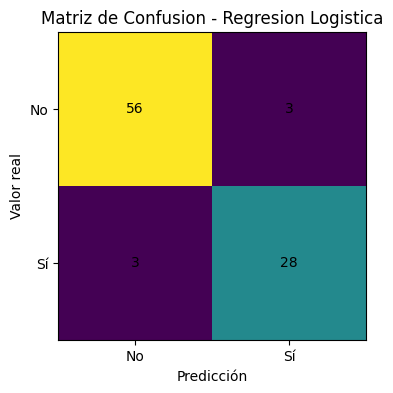

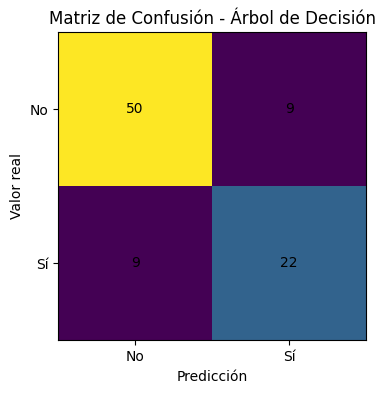

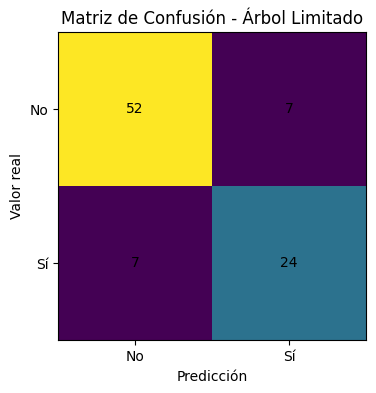


Graficos de los arboles: 



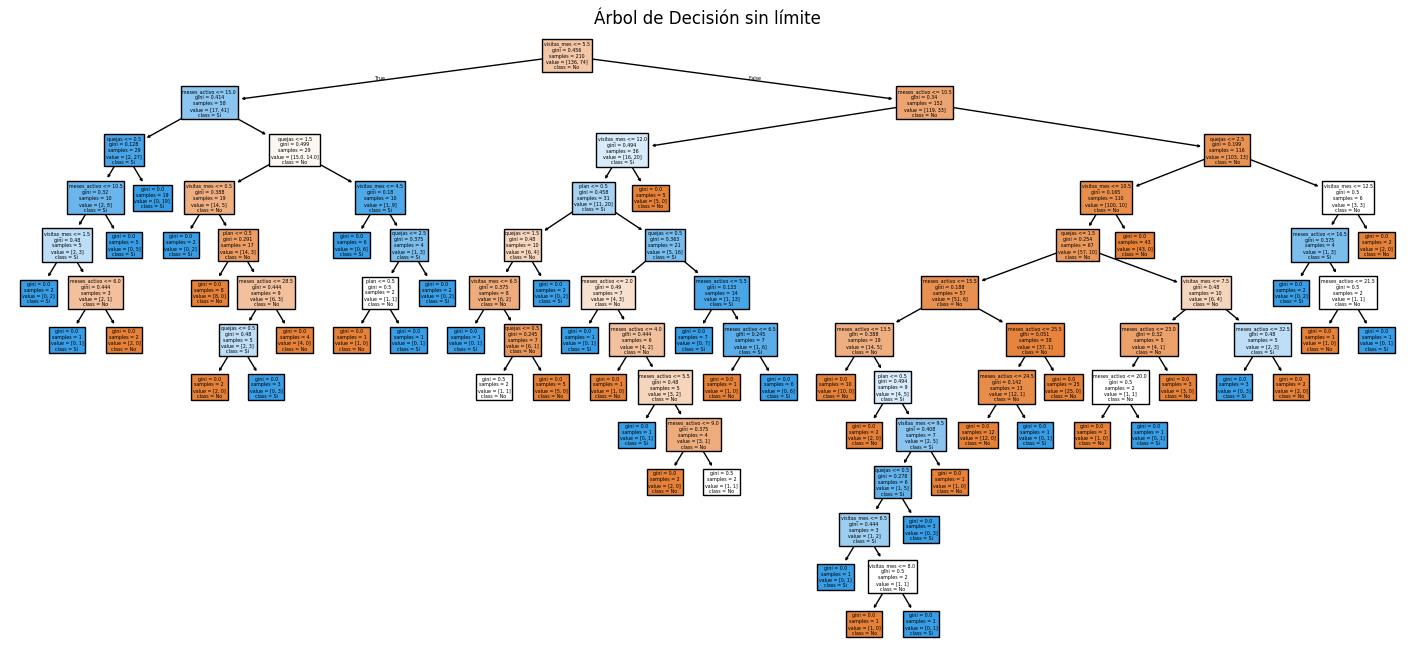

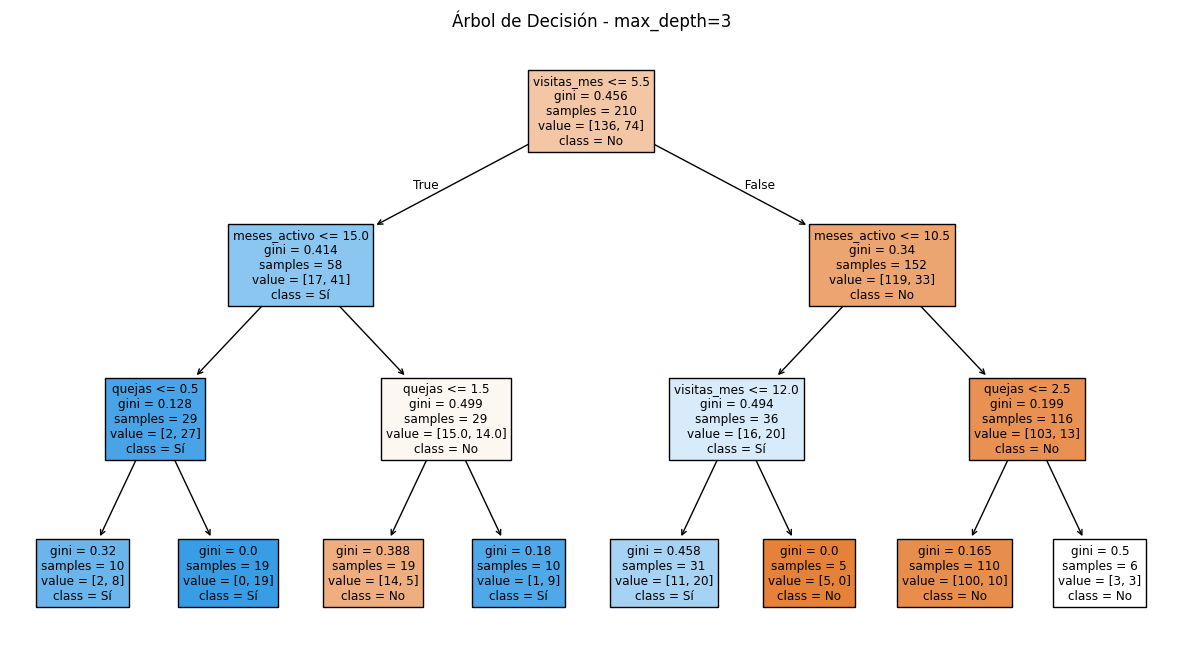


Resultados de la validacion cruzada:

Regresión Logística:
[0.86666667 0.88333333 0.91666667 0.88333333 0.83333333]
Promedio: 0.8766666666666666

Árbol sin Limite:
[0.78333333 0.83333333 0.76666667 0.83333333 0.81666667]
Promedio: 0.8066666666666666

Árbol Limitado:
[0.75       0.81666667 0.8        0.75       0.76666667]
Promedio: 0.7766666666666666


In [ ]:
#Librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix)
from google.colab import files

#-------------------------Parte B: Preparar los datos---------------------------

# Cargar el archivo #
print("Seleccione el archivo de datos:")
subido = files.upload()
nombre_archivo = list(subido.keys())[0]

print("Archivo seleccionado:", nombre_archivo)

df = pd.read_csv(nombre_archivo)

# Ver las primeras filas
print("\nPrimeras 5 filas:")
display(df.head())

# Contar cuantos socios cancelaron y cuantos no
print("\nCantidad de socios que cancelaron:")
print(df["cancelo"].value_counts())

### Convertir texto en numeros para que los modelos entiendan ###

# Convertir plan a numeros
df["plan"] = df["plan"].map({
    "Mensual": 1,
    "Anual": 0
})

# Convertir cancelo a numeros
df["cancelo"] = df["cancelo"].map({
    "Sí": 1,
    "No": 0
})

# Mostrar los datos despues de la conversión
print("\nDatos después de convertir texto a números:")
display(df.head())

### Separar los datos de entrenamiento ###

# Separar las variables de prediccion (X) y la variable objetivo (y)
X = df[["meses_activo", "visitas_mes", "quejas", "plan"]]
y = df["cancelo"]

# Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#--------------------------Parte C Entramiendo de los 3 modelos-----------------

### Entremiento ###

# Modelo 1: Regresión Logística
modelo_logistica = LogisticRegression(random_state=42)
modelo_logistica.fit(X_train, y_train)

# Modelo 2: Árbol de Decision sin límite
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)

# Modelo 3: Árbol de Decision limitado
modelo_arbol_limitado = DecisionTreeClassifier(max_depth=3,random_state=42)
modelo_arbol_limitado.fit(X_train, y_train)


### Predicciones ###
prediccion_logistica = modelo_logistica.predict(X_test)
prediccion_arbol = modelo_arbol.predict(X_test)
prediccion_arbol_limitado = modelo_arbol_limitado.predict(X_test)


print("\n--- Modelo 1: Regresion Logistica ---")
print("Exactitud",accuracy_score(y_test, prediccion_logistica))
print("Precision:", precision_score(y_test, prediccion_logistica))
print("Recall:", recall_score(y_test, prediccion_logistica))


print("\n--- Modelo 2: Arbol de Decision sin limite ---")
print("Exactitud",accuracy_score(y_test, prediccion_arbol))
print("Precision:", precision_score(y_test, prediccion_arbol))
print("Recall:", recall_score(y_test, prediccion_arbol))

print("\n--- Modelo 3: Arbol de Decisión limitado ---")
print("Exactitud",accuracy_score(y_test, prediccion_arbol_limitado))
print("Precision:", precision_score(y_test, prediccion_arbol_limitado))
print("Recall:", recall_score(y_test, prediccion_arbol_limitado))


## Matrices de Confusion ##
matriz_logistica = confusion_matrix(y_test, prediccion_logistica)

matriz_arbol = confusion_matrix(y_test, prediccion_arbol)

matriz_arbol_limitado = confusion_matrix(y_test, prediccion_arbol_limitado)

## Graficos de las matrices

print("\nMatrices de Confusion: \n")

# Modelo 1: Regresion Logistica #
plt.figure(figsize=(5, 4))
plt.imshow(matriz_logistica)
plt.title("Matriz de Confusion - Regresion Logistica")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["No", "Sí"])
plt.yticks([0, 1], ["No", "Sí"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, matriz_logistica[i, j],
                 ha="center", va="center")

plt.show()

# Modelo 2: Arbol sin Limite #
plt.figure(figsize=(5, 4))
plt.imshow(matriz_arbol)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["No", "Sí"])
plt.yticks([0, 1], ["No", "Sí"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, matriz_arbol[i, j],
                 ha="center", va="center")

plt.show()

# Modelo 3: Arbol Limitado #
plt.figure(figsize=(5, 4))
plt.imshow(matriz_arbol_limitado)
plt.title("Matriz de Confusión - Árbol Limitado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks([0, 1], ["No", "Sí"])
plt.yticks([0, 1], ["No", "Sí"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, matriz_arbol_limitado[i, j],
                 ha="center", va="center")

plt.show()

print("\nGraficos de los arboles: \n")
### Grafico del modelo 2: Arbol sin Limite ###

plt.figure(figsize=(18, 8))

plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=["No", "Sí"],
    filled=True
)

plt.title("Árbol de Decisión sin límite")
plt.show()

### Grafico del modelo 3: Arbol Limitado ###

plt.figure(figsize=(15, 8))

plot_tree(
    modelo_arbol_limitado,
    feature_names=X.columns,
    class_names=["No", "Sí"],
    filled=True
)

plt.title("Árbol de Decisión - max_depth=3")
plt.show()

### Cross Validation de los modelos ###

# Modelo 1: Regresion Logistica #
cv_logistica = cross_val_score(modelo_logistica,X,y,cv=5)

# Modelo 2: Arbol sin Limite #
cv_arbol = cross_val_score(modelo_arbol,X,y,cv=5)

# Modelo 3: Arbol Limitado #
cv_arbol_limitado = cross_val_score(modelo_arbol_limitado,X,y,cv=5)

print("\nResultados de la validacion cruzada:")

print("\nRegresión Logística:")
print(cv_logistica)
print("Promedio:", cv_logistica.mean())

print("\nÁrbol sin Limite:")
print(cv_arbol)
print("Promedio:", cv_arbol.mean())

print("\nÁrbol Limitado:")
print(cv_arbol_limitado)
print("Promedio:", cv_arbol_limitado.mean())

# **Conclusión**

Se recomienda utilizar el modelo de **Regresión Logística** porque tuvo los mejores resultados en exactitud, precisión y recall en la evaluación con los datos de prueba. Además, en la validación cruzada obtuvo el mayor promedio de exactitud, con **87.67%** siendo mas consistente que los arboles. Los dos árboles de decisión obtuvieron promedios menores en la validación cruzada. Por estas razones, la Regresión Logística resulta ser el modelo más adecuado para este conjunto de datos.
